# Logistic Regression

## Overview

**Logistic Regression** is a fundamental supervised learning algorithm for binary classification. Despite its name, it is a classification model — not a regression model. It estimates the probability that a sample belongs to a given class, then thresholds that probability to produce a class label.

Logistic Regression is widely used in medicine, finance, and natural language processing as both a strong baseline and an interpretable production model.

---

## Problem Formulation

Given features $\mathbf{x} \in \mathbb{R}^p$, the model estimates:

$$P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

where $\sigma(\cdot)$ is the **sigmoid function**, which squashes any real value into $(0, 1)$.

The final class label is assigned by thresholding at $\tau = 0.5$ by default:

$$\hat{y} = \begin{cases} 1 & \text{if } \sigma(\mathbf{w}^\top \mathbf{x} + b) \geq \tau \\ 0 & \text{otherwise} \end{cases}$$

---

## Loss Function — Binary Cross-Entropy

Parameters are learned by minimizing **binary cross-entropy** (log loss):

$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

This measures how well predicted probabilities align with true labels. It is convex in $\mathbf{w}$ and $b$, guaranteeing a unique global minimum.

---

## Gradient Descent Updates

Taking partial derivatives of the loss and applying gradient descent:

$$\mathbf{w} \leftarrow \mathbf{w} - \frac{\eta}{n} X^\top (\hat{p} - y)$$

$$b \leftarrow b - \frac{\eta}{n} \sum_{i=1}^{n}(\hat{p}_i - y_i)$$

where $\eta$ is the learning rate and $\hat{p}$ is the vector of predicted probabilities.

---

## Decision Boundary

Logistic Regression produces a **linear decision boundary** in feature space — the hyperplane where $\mathbf{w}^\top \mathbf{x} + b = 0$. Points on one side are classified as class 1, the other as class 0.

---

## Key Properties

| Property | Detail |
|---|---|
| **Type** | Binary linear classifier |
| **Output** | Probability in $(0, 1)$ |
| **Loss** | Binary cross-entropy |
| **Optimization** | Gradient descent |
| **Decision boundary** | Linear hyperplane |
| **Limitation** | Cannot model non-linear boundaries without feature engineering |

 EXPERIMENT 1 — Decision Boundary (Synthetic)


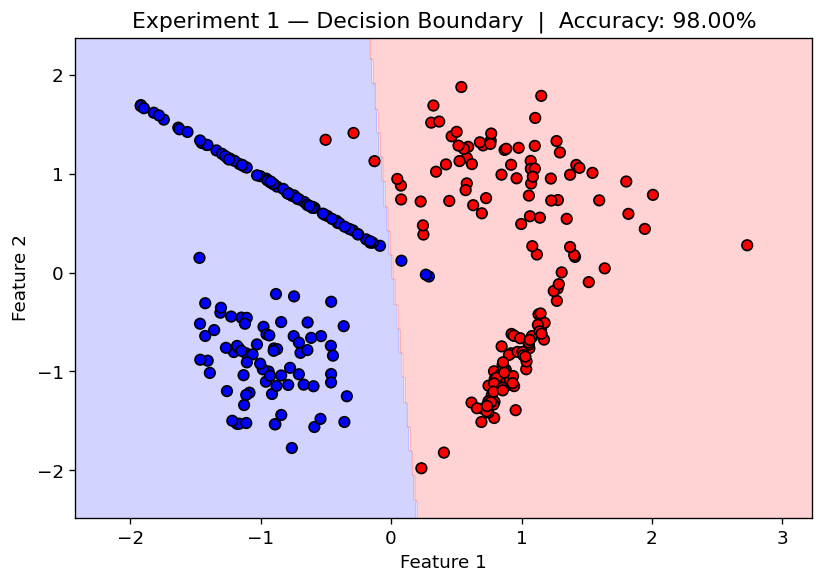

Accuracy: 98.00%

 EXPERIMENT 2 — Loss Convergence


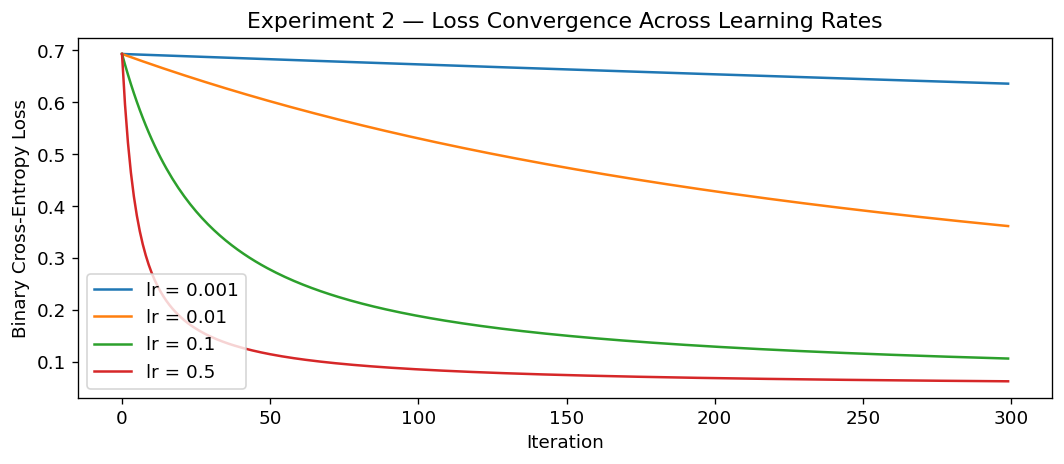

 EXPERIMENT 3 — Decision Threshold Analysis


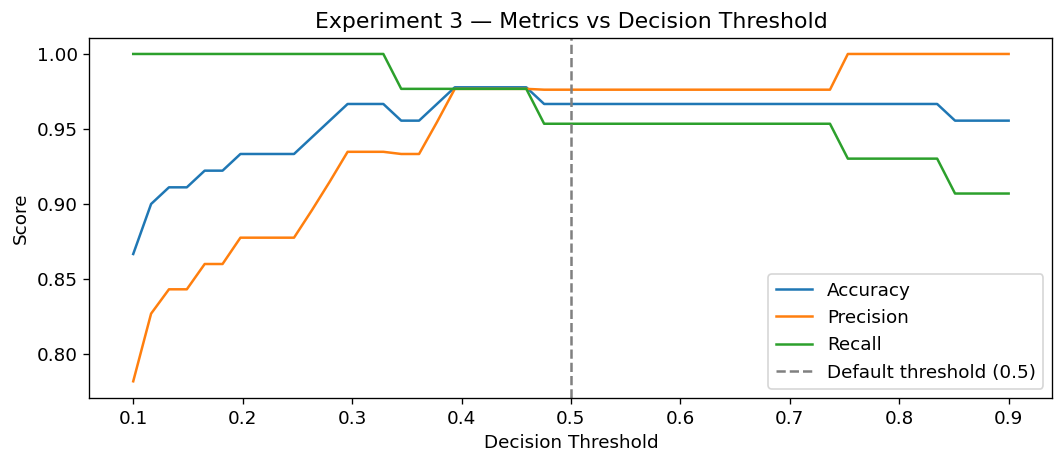

 EXPERIMENT 4 — Breast Cancer Dataset
Test Accuracy : 97.37%

              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



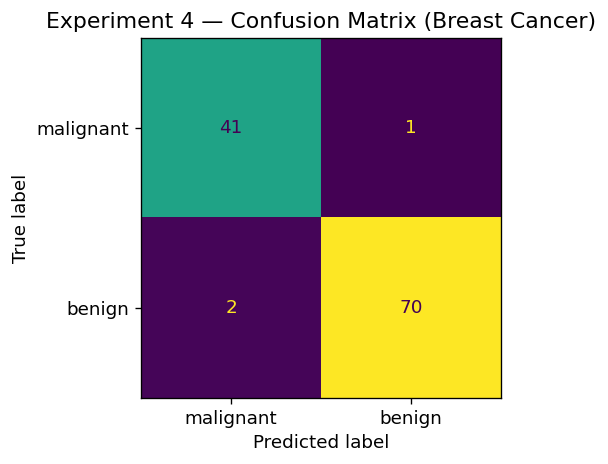

 EXPERIMENT 5 — ROC Curve & AUC


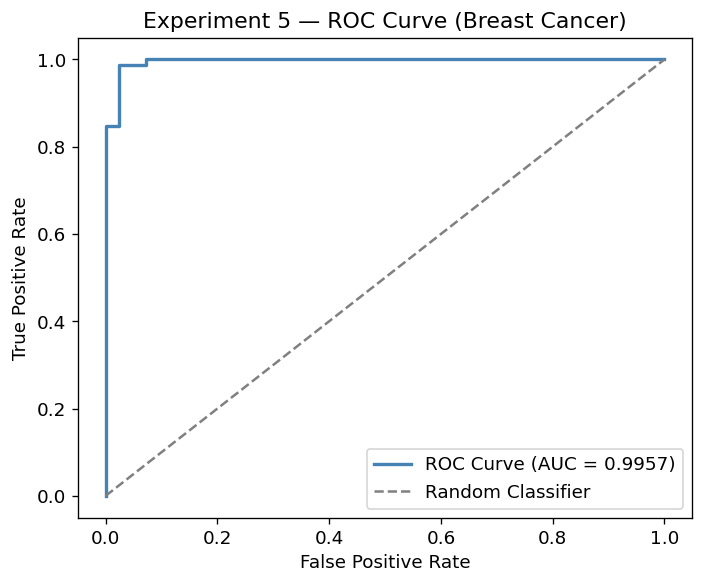

AUC: 0.9957


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
import sys, os
sys.path.append(os.path.abspath("../../"))
from mlpackage import LogisticRegression

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


# ── Helper: decision boundary ─────────────────────────────────────────────────
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap="bwr")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", s=40)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


# ── 1. Decision Boundary on Synthetic Data ────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — Decision Boundary (Synthetic)")
print("=" * 55)

X_syn, y_syn = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, random_state=42, class_sep=1.5)
X_syn = StandardScaler().fit_transform(X_syn)

model_syn = LogisticRegression(learning_rate=0.1, n_iters=500)
model_syn.fit(X_syn, y_syn)

fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(model_syn, X_syn, y_syn, ax,
    f"Experiment 1 — Decision Boundary  |  Accuracy: {model_syn.score(X_syn, y_syn):.2%}")
plt.tight_layout()
plt.show()
print(f"Accuracy: {model_syn.score(X_syn, y_syn):.2%}\n")


# ── 2. Loss Convergence Across Learning Rates ─────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — Loss Convergence")
print("=" * 55)

learning_rates = [0.001, 0.01, 0.1, 0.5]
fig, ax = plt.subplots(figsize=(9, 4))
for lr in learning_rates:
    m = LogisticRegression(learning_rate=lr, n_iters=300)
    m.fit(X_syn, y_syn)
    ax.plot(m.loss_history, label=f"lr = {lr}")

ax.set_xlabel("Iteration")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.set_title("Experiment 2 — Loss Convergence Across Learning Rates")
ax.legend()
plt.tight_layout()
plt.show()


# ── 3. Effect of Decision Threshold ──────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 3 — Decision Threshold Analysis")
print("=" * 55)

X_tr, X_te, y_tr, y_te = train_test_split(X_syn, y_syn, test_size=0.3, random_state=42)
model_thr = LogisticRegression(learning_rate=0.1, n_iters=500)
model_thr.fit(X_tr, y_tr)
proba = model_thr.predict_proba(X_te)

thresholds = np.linspace(0.1, 0.9, 50)
precisions, recalls, accuracies = [], [], []
for t in thresholds:
    preds = (proba >= t).astype(int)
    accuracies.append(np.mean(preds == y_te))
    tp = np.sum((preds == 1) & (y_te == 1))
    fp = np.sum((preds == 1) & (y_te == 0))
    fn = np.sum((preds == 0) & (y_te == 1))
    precisions.append(tp / (tp + fp + 1e-9))
    recalls.append(tp / (tp + fn + 1e-9))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, accuracies, label="Accuracy")
ax.plot(thresholds, precisions, label="Precision")
ax.plot(thresholds, recalls,    label="Recall")
ax.axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Experiment 3 — Metrics vs Decision Threshold")
ax.legend()
plt.tight_layout()
plt.show()


# ── 4. Real Dataset — Breast Cancer ──────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 4 — Breast Cancer Dataset")
print("=" * 55)

data = load_breast_cancer()
X_raw, y_raw = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s  = sc.transform(X_te)

clf = LogisticRegression(learning_rate=0.1, n_iters=500)
clf.fit(X_tr_s, y_tr)
y_pred = clf.predict(X_te_s)

print(f"Test Accuracy : {clf.score(X_te_s, y_te):.2%}\n")
print(classification_report(y_te, y_pred, target_names=data.target_names))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
                       display_labels=data.target_names).plot(ax=ax, colorbar=False)
ax.set_title("Experiment 4 — Confusion Matrix (Breast Cancer)")
plt.tight_layout()
plt.show()


# ── 5. ROC Curve & AUC ───────────────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 5 — ROC Curve & AUC")
print("=" * 55)

proba_test = clf.predict_proba(X_te_s)
fpr, tpr, _ = roc_curve(y_te, proba_test)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Experiment 5 — ROC Curve (Breast Cancer)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"AUC: {roc_auc:.4f}")